## Imports

In [1]:
%load_ext autoreload
%autoreload 2

import logging

from matplotlib import pyplot as plt
import numpy as np
import pandas as pd

In [2]:
import helpers.hdbg as hdbg
import helpers.hnotebook as hnotebo

import msml610_utils as ut
import L08_04_07_metalearners_utils as mtl

ut.config_notebook()

# Initialize logger.
logging.basicConfig(level=logging.INFO)
_LOG = logging.getLogger(__name__)
hnotebo.set_logger_to_print(_LOG)
hnotebo.set_all_loggers_to_print()

pymc is not installed
arviz is not installed
preliz is not installed
sns is not installed


Python 3.12.13
Linux 3a71c0a7bf16 6.12.67-linuxkit #1 SMP Sun Jan 25 02:26:28 UTC 2026 aarch64 GNU/Linux


In [3]:
import helpers.hmodule as hmodule

hmodule.install_module_if_not_present(
    ["lightgbm", "fklearn"],
    use_activate=True,
    use_sudo=False,
    venv_path="/opt/venv"
)

Module 'lightgbm' is already installed.
Module 'fklearn' is already installed.


# Load data

In [4]:
dir_name = "L08_data"
#!ls $dir_name

out_dir_name = "figures/"

In [5]:
data_biased = pd.read_csv(f"{dir_name}/email_obs_data.csv")
print("# data_biased")
print("num_rows=", len(data_biased))
display(data_biased.head())

data_rnd = pd.read_csv(f"{dir_name}/email_rnd_data.csv")
print("# data_rnd")
print("num_rows=", len(data_rnd))
display(data_rnd.head())

# data_biased
num_rows= 300000


,mkt_email,next_mnth_pv,age,tenure,ammount_spent,vehicle,food,beverage,art,baby,...,electronics,sports,tools,games,industry,pc,jewel,books,music_books_movies,health
0,0,34.38,32.0,0.0,18.05,0,0,1,1,1,...,3,0,1,0,1,2,2,0,1,1
1,0,183.14,23.0,1.0,182.97,0,0,0,1,0,...,1,1,0,0,0,2,2,1,2,1
2,0,54.26,29.0,0.0,29.57,0,0,0,1,4,...,3,0,0,0,3,0,0,0,1,4
3,1,1409.71,44.0,0.0,142.15,1,2,0,1,0,...,1,0,1,1,1,3,0,1,0,5
4,0,120.16,30.0,0.0,132.11,0,1,1,0,1,...,1,2,1,1,2,3,0,0,2,5


# data_rnd
num_rows= 10000


,mkt_email,next_mnth_pv,age,tenure,ammount_spent,vehicle,food,beverage,art,baby,...,electronics,sports,tools,games,industry,pc,jewel,books,music_books_movies,health
0,0,244.26,61.0,1.0,21.84,0,2,2,0,2,...,1,0,0,3,1,0,1,0,0,2
1,0,29.67,36.0,1.0,107.40,0,2,0,2,0,...,1,1,1,2,1,2,1,0,2,2
2,0,11.73,64.0,0.0,59.81,0,1,0,0,0,...,2,0,0,3,0,1,0,1,0,1
3,0,41.41,74.0,0.0,62.98,0,1,0,0,3,...,1,0,2,2,1,1,0,4,1,0
4,0,447.89,59.0,0.0,72.56,0,1,1,3,2,...,5,0,0,1,0,0,1,1,2,1


In [6]:
hdbg.dassert_eq(data_biased.columns.tolist(), data_rnd.columns.tolist())

In [7]:
y = "next_mnth_pv"
T = "mkt_email"
X = list(data_rnd.drop(columns=[y, T]).columns)

train, test = data_biased, data_rnd

In [8]:
display(train[[T, y]].head())

,mkt_email,next_mnth_pv
0,0,34.38
1,0,183.14
2,0,54.26
3,1,1409.71
4,0,120.16


# T-Learner

In [9]:
from lightgbm import LGBMRegressor

np.random.seed(123)

m0 = LGBMRegressor()
m1 = LGBMRegressor()

m0.fit(train.query(f"{T}==0")[X], train.query(f"{T}==0")[y])
m1.fit(train.query(f"{T}==1")[X], train.query(f"{T}==1")[y]);

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010238 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 548
[LightGBM] [Info] Number of data points in the train set: 146759, number of used features: 25
[LightGBM] [Info] Start training from score 88.249324
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005045 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 550
[LightGBM] [Info] Number of data points in the train set: 153241, number of used features: 25
[LightGBM] [Info] Start training from score 1596.224063


In [10]:
m0

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [11]:
t_learner_cate_test = test.assign(
    cate=m1.predict(test[X]) - m0.predict(test[X])
)

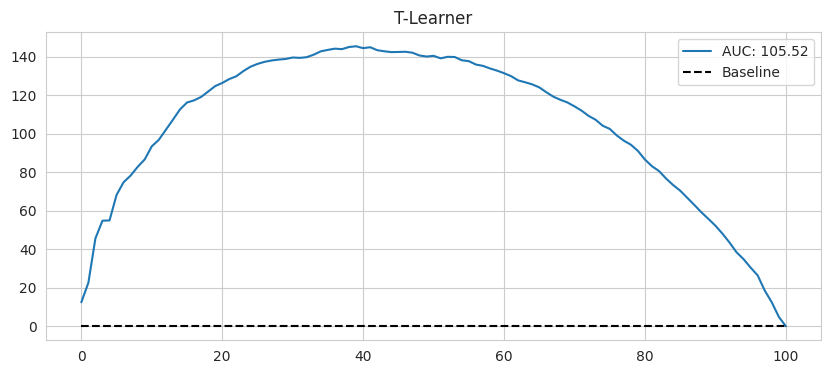

In [12]:
import fklearn.causal.validation.curves
import fklearn.causal.validation.auc

gain_curve_test = fklearn.causal.validation.curves.relative_cumulative_gain_curve(t_learner_cate_test, T, y, prediction="cate")
auc = fklearn.causal.validation.auc.area_under_the_relative_cumulative_gain_curve(t_learner_cate_test, T, y, prediction="cate")

plt.figure(figsize=(10,4))
plt.plot(gain_curve_test, color="C0", label=f"AUC: {auc:.2f}")
plt.hlines(0, 0, 100, linestyle="--", color="black", label="Baseline")

plt.legend();
_ = plt.title("T-Learner")

In [19]:
import warnings, logging
warnings.filterwarnings('ignore', category=UserWarning, module='lightgbm')

logging.getLogger("lightgbm").setLevel(logging.ERROR)

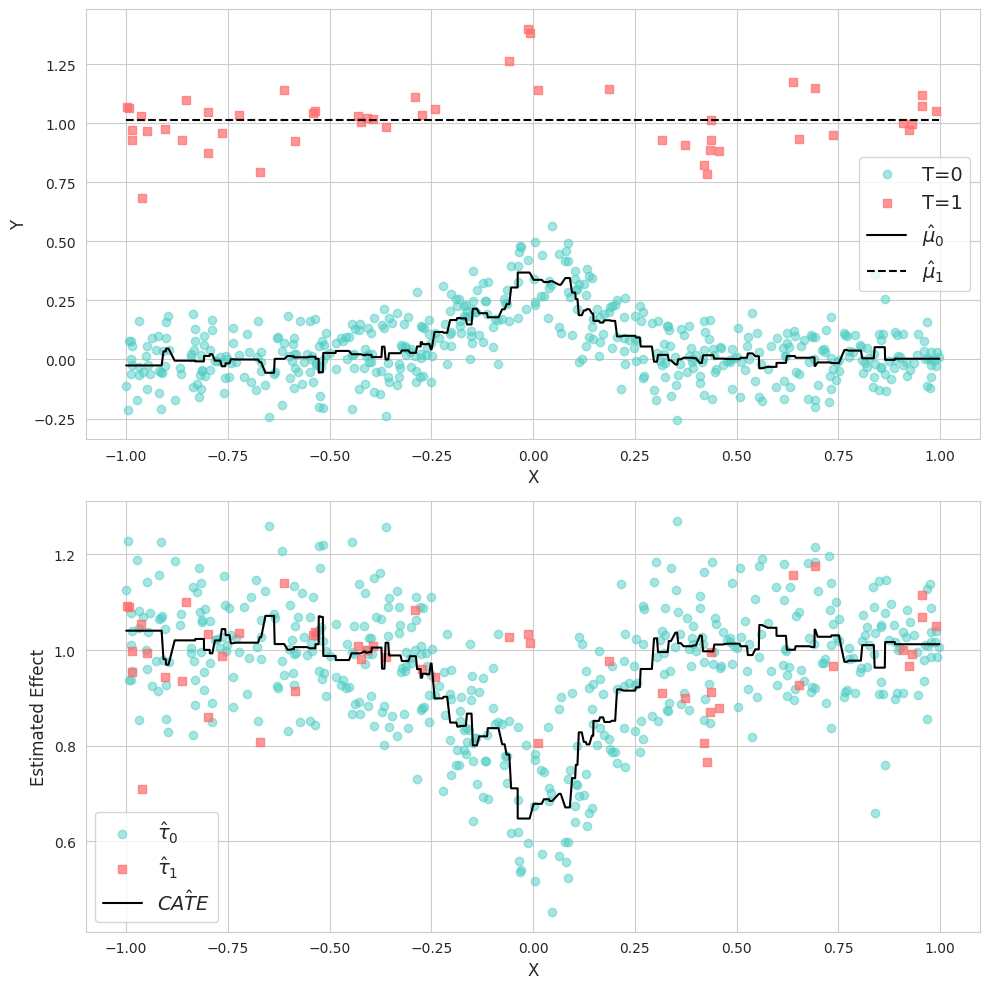

In [21]:
# TODO(ai_gp): Make the plots smaller.

# Generate synthetic data with treatment heterogeneity.
df = mtl.generate_synthetic_treatment_data(n0=500, n1=50, seed=123)

# Fit separate outcome models for control and treatment groups.
m0, m1, m0_hat, m1_hat = mtl.fit_outcome_models(df, min_child_samples=25)

# Visualize outcome models and heterogeneous treatment effects.
mtl.plot_treatment_effect_analysis(df, m0, m1, m0_hat, m1_hat)

# X-Learner

In [ ]:
# TODO(ai_gp): Move to utils and add comments.

from sklearn.linear_model import LogisticRegression

np.random.seed(1)

mu_tau0 = LGBMRegressor(min_child_samples=25)
mu_tau1 = LGBMRegressor(min_child_samples=25)

mu_tau0.fit(df.query("t==0")[["x"]], tau_0)
mu_tau1.fit(df.query("t==1")[["x"]], tau_1)

mu_tau0_hat = mu_tau0.predict(df.query("t==0")[["x"]])
mu_tau1_hat = mu_tau1.predict(df.query("t==1")[["x"]])

plt.figure(figsize=(10, 4))
plt.scatter(df.query("t==0")[["x"]], tau_0, label="$\hat{\\tau_0}$", alpha=0.5, marker=marker[0], color=color[1])
plt.scatter(df.query("t==1")[["x"]], tau_1, label="$\hat{\\tau_1}$", alpha=0.8, marker=marker[1], color=color[0])
plt.plot(df.query("t==0")[["x"]], mu_tau0_hat, color="black", linestyle="solid", label="$\hat{\mu}\\tau 0$")
plt.plot(df.query("t==1")[["x"]], mu_tau1_hat, color="black", linestyle="dashed", label="$\hat{\mu}\\tau_1$")
plt.ylabel("Estimated Effect")
plt.xlabel("X")
plt.legend(fontsize=14)

In [ ]:
# TODO(ai_gp): Move to utils and add comments.

plt.figure(figsize=(10, 4))

ps_model = LogisticRegression(penalty="none")
ps_model.fit(df[["x"]], df["t"])

ps = ps_model.predict_proba(df[["x"]])[:, 1]

cate = ((1-ps)*mu_tau1.predict(df[["x"]]) +
        ps*mu_tau0.predict(df[["x"]]))

plt.scatter(df.query("t==0")[["x"]], tau_0, label="$\hat{\\tau_0}$", alpha=0.5, s=100*(ps[df["t"]==0]),   marker=marker[0], color=color[1])
plt.scatter(df.query("t==1")[["x"]], tau_1, label="$\hat{\\tau_1}$", alpha=0.5, s=100*(1-ps[df["t"]==1]), marker=marker[1], color=color[0])

plt.plot(df[["x"]], cate, label="x-learner", color="black")
plt.ylabel("Estimated Effect")
plt.xlabel("X")
plt.legend(fontsize=14)